<a href="https://colab.research.google.com/github/fatahrahimi330/XST-Deepfake-Detection/blob/master/Model/Main_Model_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Main Model CNN+ViT+BiLSTM

## 1. Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from timm import create_model
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

## 2. Loading Dataset

In [ ]:
!rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/"
print(os.listdir(path))


['.DS_Store', 'val', 'train', 'test']


In [ ]:
len(path)

61

## 3. Data Preprocessing

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ViT standard size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=path+'train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=path+'val',
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=path+'test',
    transform=val_test_transform
)

In [ ]:
print(train_dataset.classes)

['fake', 'real']


In [ ]:
# Calculate 100% of the training data size
train_size = int(1.0 * len(train_dataset))
subset_indices = list(range(train_size))
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)

In [ ]:
# Calculate 100% of the validation data size
val_size = int(1.0 * len(val_dataset))
subset_indices_val = list(range(val_size))
val_subset = torch.utils.data.Subset(val_dataset, subset_indices_val)

In [ ]:
# Calculate 100% of the test data size
test_size = int(1.0 * len(test_dataset))
subset_indices_test = list(range(test_size))
test_subset = torch.utils.data.Subset(test_dataset, subset_indices_test)

In [ ]:
train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
import numpy as np
from tqdm import tqdm

labels = []
for _, y in tqdm(train_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 14/14 [01:34<00:00,  6.76s/it]

[0]


In [ ]:
labels = []
for _, y in tqdm(val_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 3/3 [00:24<00:00,  8.16s/it]

[0]


In [ ]:
labels = []
for _, y in tqdm(test_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 4/4 [00:27<00:00,  6.94s/it]

[0]


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)   # (32, 3, 224, 224)
print(labels.shape)


torch.Size([16, 3, 224, 224])
torch.Size([16])


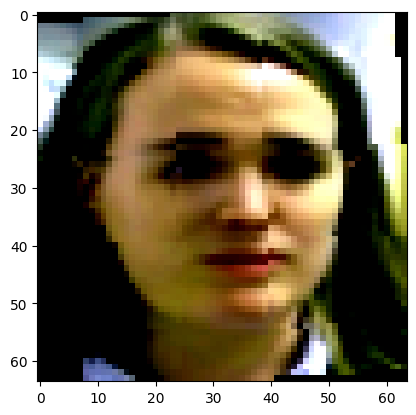

In [ ]:
import matplotlib.pyplot as plt

def imshow(img):
    img = img / 2 + 0.5   # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(images[5])


## 4. Build the Model

In [ ]:
import torch
import torch.nn as nn
import timm

class CNN_ViT_BiLSTM(nn.Module):
    def __init__(self, cnn_model='efficientnet_b0', vit_model='vit_base_patch16_224', lstm_hidden=256, lstm_layers=1):
        super(CNN_ViT_BiLSTM, self).__init__()

        # CNN backbone (pretrained)
        self.cnn = timm.create_model(cnn_model, pretrained=True)
        self.cnn.reset_classifier(0)  # remove classifier to get features
        cnn_feature_dim = self.cnn.num_features

        # ViT backbone (pretrained)
        self.vit = timm.create_model(vit_model, pretrained=True)
        self.vit.reset_classifier(0)
        vit_feature_dim = self.vit.num_features

        # BiLSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=cnn_feature_dim + vit_feature_dim, # Corrected input size
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        # Fully connected layer for binary output
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden*2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        """
        x: shape (B, T, C, H, W)
        B = batch size, T = number of frames per video
        """
        B, T, C, H, W = x.shape
        x_flat = x.view(B*T, C, H, W) # Flatten B and T dimensions for CNN and ViT processing

        # CNN feature extraction from original images
        cnn_raw_feat = self.cnn.forward_features(x_flat)
        # Apply global pooling and flatten for CNN
        cnn_feat = self.cnn.global_pool(cnn_raw_feat).flatten(1)

        # ViT feature extraction from original images (parallel processing)
        vit_raw_feat = self.vit.forward_features(x_flat)
        # Extract CLS token for ViT
        vit_feat = vit_raw_feat[:, 0]

        # Concatenate features
        combined_feat = torch.cat((cnn_feat, vit_feat), dim=1) # Combine features

        # Reshape to sequence for LSTM
        seq_feat = combined_feat.view(B, T, -1)

        # BiLSTM
        lstm_out, _ = self.lstm(seq_feat)  # lstm_out: (B, T, 2*hidden)
        lstm_last = lstm_out[:, -1, :]     # take last frame output

        # FC layer
        out = self.fc(lstm_last)
        return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_ViT_BiLSTM().to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
model.parameters()

## 5. Loop and Fit the Model

In [ ]:
from tqdm import tqdm
import os
import torch
import matplotlib.pyplot as plt

# Paths
checkpoint_path = "/content/drive/MyDrive/XST-Deepfake-Detection/Models/checkpoint.pth"
best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/Models/best_model.pth"

# Early stopping settings
patience = 3
counter = 0
best_val_loss = float('inf')

start_epoch = 0

# Initialize metric lists
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Resume if checkpoint exists
if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    counter = checkpoint.get('counter', 0)

    # LOAD METRICS (IMPORTANT)
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    train_accuracies = checkpoint.get('train_accuracies', [])
    val_accuracies = checkpoint.get('val_accuracies', [])

    print(f"Resuming from epoch {start_epoch}")

epochs = 15

for epoch in range(start_epoch, epochs):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        images = images.unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        train_correct += (preds == labels.int()).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            images = images.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # SAVE METRICS
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Check for improvement
    if val_loss < best_val_loss:
        print("✅ Validation improved — saving best model")

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    # Save checkpoint (WITH METRICS)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
        'counter': counter,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }, checkpoint_path)

    # Early stopping
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Loading checkpoint...
Resuming from epoch 6


 83%|████████▎ | 559/677 [2:37:42<35:41, 18.15s/it]

In [ ]:
# =========================
# 📊 PLOT AFTER TRAINING
# =========================

epochs_range = range(1, len(train_losses) + 1)

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/loss_curve.png")
plt.show()

In [ ]:
# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/accuracy_curve.png")
plt.show()

## 6. Make Prediction

In [ ]:
from PIL import Image

def predict_image(model, image_path, device):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).int()

    return pred.item(), prob.item()

In [ ]:
classes = val_dataset.classes
url = "/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/val/real/01__podium_speech_happy/0000.jpg"
label, prob = predict_image(model, url, device)

print(f"Prediction: {classes[label]} ({prob:.2f})")

Prediction: fake (0.00)


## 7. Evaluate the Model

In [ ]:
import torch

def test_model(model, test_loader, device):
    model.eval()  # evaluation mode
    correct = 0
    total = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():  # no gradients
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape (B,1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    return all_preds, all_labels, all_probs

In [ ]:
all_preds, all_labels, all_probs = test_model(model, test_loader, device)

Test Accuracy: 1.0000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get unique labels present
unique_labels = np.unique(all_labels).astype(int)
present_target_names = [classes[l] for l in unique_labels]

# 📊 Classification report
print(classification_report(
    all_labels,
    all_preds,
    labels=unique_labels,
    target_names=present_target_names
))

# Confusion matrix (raw values)
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
print("Confusion Matrix:\n", cm)

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_target_names)

plt.figure()
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

# Save to Drive (optional)
plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/confusion_matrix.png")

plt.show()

# AUC score
print("AUC:", roc_auc_score(all_labels, all_probs))

              precision    recall  f1-score   support

        fake       1.00      1.00      1.00       255

    accuracy                           1.00       255
   macro avg       1.00      1.00      1.00       255
weighted avg       1.00      1.00      1.00       255

[[255]]
AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## 8. Save and Load the Model

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.eval()